# Week 3 · Notebook 1 — Tabu Search Fundamentals

**Goals**
- Define tabu search (TS) precisely as a trajectory method with *adaptive memory*: a neighbourhood, a
  best-admissible-move selection rule, an attribute-based short-term memory (the tabu list) with a tenure,
  aspiration criteria and candidate lists.
- Explain why tabu lists store move *attributes* rather than full solutions, and what that costs.
- Derive the $O(n)$ swap-move delta for the quadratic assignment problem (QAP) and Taillard's $O(1)$-per-entry
  update of the delta matrix ($O(n^2)$ per iteration for the whole matrix), and validate both against full
  recomputation.
- Validate a complete TS for the QAP against exhaustive enumeration (`qap_brute_force`, $n \le 9$).
- Demonstrate *cycling* when the tenure is zero, prove why it must happen, and measure solution quality as a
  function of tenure over many seeds at a fixed evaluation budget.

**Prerequisites:** Week 1 (neighbourhoods, local optima, best- vs first-improvement), Week 2 (SA acceptance,
evaluation budgets).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import time
from utils import random_qap, qap_cost, qap_brute_force, PALETTE

## 1. From local search to tabu search

Local search stops at the first local optimum. Simulated annealing (Week 2) escapes by *randomised acceptance*.
Tabu search escapes by a *deterministic* rule instead: at every iteration it moves to the **best admissible
neighbour, even if that neighbour is worse** than the current solution. Taken alone this rule is useless —
after an uphill step the best move is usually to step straight back down — so TS adds a **memory** that
forbids ("makes tabu") moves that would undo recent decisions.

The method was proposed and named by **Fred Glover (1986)**, *"Future paths for integer programming and links
to artificial intelligence"* (Computers & Operations Research 13(5)), and developed in *"Tabu Search — Part I"*
(ORSA Journal on Computing, 1989) and *"Part II"* (1990). Pierre Hansen independently described the closely
related *steepest ascent / mildest descent* heuristic in 1986. The standard reference is Glover & Laguna,
*Tabu Search* (Kluwer, 1997).

**Mechanisms (metaphor-free).** Let $S$ be a finite search space, $f: S \to \mathbb{R}$ to be minimised,
$N(x) \subseteq S$ a neighbourhood generated by a set of *moves* $m$, $x' = x \oplus m$.

| Mechanism | Tabu search choice |
|---|---|
| Representation | problem-specific (here: permutation) |
| Neighbourhood | full or sampled (candidate list) move set $M(x)$ |
| Selection / acceptance | deterministic: best **admissible** move, always accepted, even if $\Delta \gt 0$ |
| Memory | short-term: recency of move attributes (tabu list, tenure $t$); long-term: frequencies, elites (Notebook 2) |
| Stochasticity | none required; optional (random tenure, random candidate lists, tie breaking) |

**Definitions.**
- A *move attribute* $a(m)$ is a small piece of information about a move, e.g. "facility $i$ left location $\ell$".
- The *tabu list* stores, for each attribute, the iteration until which it is forbidden: `tabu_until[a]`.
  An attribute made tabu at iteration $k_0$ gets `tabu_until[a] = k_0 + t`, so it is tabu during iterations
  $k_0+1, \dots, k_0+t$ (test: `tabu_until[a] >= k`). The *tenure* $t$ is how long an attribute stays tabu.
- A move is **tabu** if its attributes are tabu (a *tabu-activation rule* specifies which combination).
- An **aspiration criterion** overrides tabu status. The universal one is *aspiration by objective*: a tabu move
  is admissible if $f(x \oplus m) \lt f(x^{\ast})$, the best value ever found — such a move cannot lead back to an
  already visited solution.
- A **candidate list** restricts $M(x)$ to a (possibly random or strategically chosen) subset, trading
  neighbourhood quality for evaluations per iteration.

```text
TabuSearch(x0, tenure t, iterations K)
  x <- x0 ; x* <- x0 ; tabu_until[.] <- 0
  for k = 1..K:
      C <- candidate moves of x                          # full neighbourhood or candidate list
      A <- { m in C : not tabu(m, k)  or  f(x+m) < f(x*) }   # admissible = non-tabu or aspirated
      m* <- argmin_{m in A} f(x+m)                       # best admissible, possibly uphill
      for each attribute a that m* destroys: tabu_until[a] <- k + t
      x <- x + m*
      if f(x) < f(x*): x* <- x
  return x*
```

**Why attributes, not solutions?** A literal tabu list of visited solutions would be *exact*: it forbids precisely
the revisits. But (i) storing and comparing solutions costs $O(n)$ memory and time per entry, and a list long
enough to block cycles of length $L$ must hold $L$ solutions; (ii) to test each of the $|M(x)| = n(n-1)/2$
neighbours against the list one must hash every *neighbour*, not just the current solution; (iii) a solution list
only forbids exact repeats, so the search can still wander in a tiny region (revisiting near-copies). An attribute
memory is $O(1)$ per test and forbids a whole *region* of recently undone decisions. The price is that it is
**over-restrictive**: it also forbids never-visited solutions that happen to share a tabu attribute. This is the
reason aspiration criteria exist. (Reactive TS, Notebook 2, reintroduces solution memory via hashing for a
different purpose: to *measure* cycling.)

## 2. The quadratic assignment problem and the swap neighbourhood

QAP (Koopmans & Beckmann, 1957): $n$ facilities, $n$ locations, flow matrix $F$, distance matrix $D$; a
permutation $\pi$ places facility $i$ at location $\pi_i$ and costs

$$
C(\pi) = \sum_{i=1}^{n} \sum_{j=1}^{n} F_{ij} \, D_{\pi_i \pi_j}.
$$

QAP is NP-hard (Sahni & Gonzalez, 1976) and notoriously hard in practice; it was the showcase problem of robust
tabu search (Taillard, 1991). The **swap** move $(r,s)$ exchanges the locations of facilities $r$ and $s$;
$|N(\pi)| = n(n-1)/2$.

**Delta evaluation (symmetric $F$, $D$ with zero diagonal, as produced by `random_qap`).** Let $\pi'$ be $\pi$
with $\pi_r$ and $\pi_s$ exchanged. Only terms with $i$ or $j \in \lbrace r,s \rbrace$ change. Write
$d_{ij} = D_{\pi_i \pi_j}$. Terms with $i = r$, $j = k \notin \lbrace r,s \rbrace$ change from $F_{rk} d_{rk}$ to
$F_{rk} d_{sk}$; with $i = s$ from $F_{sk} d_{sk}$ to $F_{sk} d_{rk}$; the terms with $j \in \lbrace r,s \rbrace$
are their mirror images (symmetry) and the $(r,s)$, $(s,r)$ terms are unchanged because $d_{rs} = d_{sr}$. Hence

$$
\Delta(\pi; r,s) = 2 \sum_{k \ne r,s} (F_{kr} - F_{ks}) \, (d_{ks} - d_{kr}),
$$

an $O(n)$ computation versus $O(n^2)$ for $C(\pi')$. Summed over all $k$ (including $k = r, s$) the two extra
terms both equal $-F_{rs} d_{rs}$, so with $M = F \, [d_{ij}]$ the whole delta matrix is
$\Delta_{rs} = 2 (M_{rs} + M_{sr} - M_{rr} - M_{ss} + 2 F_{rs} d_{rs})$ — one $O(n^3)$ matrix product.

**Taillard's $O(1)$ update (1991).** After performing swap $(r,s)$ and obtaining $\pi'$, for every pair
$\lbrace u, v \rbrace$ disjoint from $\lbrace r, s \rbrace$,

$$
\Delta(\pi'; u,v) = \Delta(\pi; u,v) + 2 (F_{ru} - F_{rv} + F_{sv} - F_{su})
(D_{\pi'_s \pi'_u} - D_{\pi'_s \pi'_v} + D_{\pi'_r \pi'_v} - D_{\pi'_r \pi'_u}).
$$

*Proof sketch.* In $\Delta(\cdot; u,v)$ only the summands with $k \in \lbrace r,s \rbrace$ depend on the
locations of $r$ and $s$; subtracting the old from the new $k=r$ and $k=s$ summands and using
$\pi'_r = \pi_s$, $\pi'_s = \pi_r$ gives exactly the product above. $\square$
With $a = F_{r\cdot} - F_{s\cdot}$ and $b = D_{\pi'_s \pi'_\cdot} - D_{\pi'_r \pi'_\cdot}$ the correction is
$2 (a_u - a_v)(b_u - b_v)$, an outer-difference product. The $2n-3$ pairs touching $r$ or $s$ are recomputed with
the $O(n)$ formula, so one full-neighbourhood TS iteration costs $O(n^2)$ instead of $O(n^3)$.

In [2]:
def qap_delta(p, r, s, F, D):
    """O(n) cost change of swapping the locations of facilities r and s (symmetric F, D, zero diagonal)."""
    dF = F[:, r] - F[:, s]
    dD = D[p, p[s]] - D[p, p[r]]
    # the full sum includes k = r and k = s, each contributing -F_rs * d_rs; add them back
    return 2.0 * (dF @ dD + 2.0 * F[r, s] * D[p[r], p[s]])


def qap_delta_matrix(p, F, D):
    """All n x n swap deltas in one O(n^3) matrix product (diagonal = 0)."""
    Dp = D[np.ix_(p, p)]
    M = F @ Dp
    dg = np.diag(M)
    Delta = 2.0 * (M + M.T - dg[:, None] - dg[None, :] + 2.0 * F * Dp)
    np.fill_diagonal(Delta, 0.0)
    return Delta


def qap_rows(p, idx, F, D):
    """Exact delta rows Delta[i, :] for i in idx, O(n^2) each call (O(n) per entry)."""
    Dp = D[np.ix_(p, p)]
    diagM = np.sum(F * Dp, axis=0)            # M_vv = sum_k F_kv d_kv
    out = []
    for r in idx:
        Mr_row = F[:, r] @ Dp                  # M_rv
        Mr_col = Dp[:, r] @ F                  # M_vr
        row = 2.0 * (Mr_row + Mr_col - diagM[r] - diagM + 2.0 * F[r] * Dp[r])
        row[r] = 0.0
        out.append(row)
    return out


def qap_update_after_swap(Delta, q, r, s, F, D):
    """Taillard's update: given Delta for the permutation *before* swap (r,s) and q = permutation *after* it,
    return the delta matrix for q in O(n^2)."""
    a = F[r] - F[s]
    b = D[q[s], q] - D[q[r], q]
    new = Delta + 2.0 * np.subtract.outer(a, a) * np.subtract.outer(b, b)
    rows = qap_rows(q, (r, s), F, D)
    for i, row in zip((r, s), rows):
        new[i, :] = row
        new[:, i] = row
    np.fill_diagonal(new, 0.0)
    return new

### Validation of the delta formulas against full recomputation

Each check compares the formula with an independent computation: `qap_cost` of the explicitly swapped
permutation minus `qap_cost` of the original ($O(n^2)$ each, straight from the definition).

In [3]:
def brute_delta_matrix(p, F, D):
    n, c = len(p), qap_cost(p, F, D)
    out = np.zeros((n, n))
    for r in range(n):
        for s in range(r + 1, n):
            q = p.copy(); q[[r, s]] = q[[s, r]]
            out[r, s] = out[s, r] = qap_cost(q, F, D) - c
    return out

Fv, Dv = random_qap(15, rng)
p = rng.permutation(15)
B = brute_delta_matrix(p, Fv, Dv)
O_n = np.array([[qap_delta(p, r, s, Fv, Dv) if r != s else 0.0 for s in range(15)] for r in range(15)])
check_close(np.abs(O_n - B).max(), 0.0, "O(n) swap delta vs full recomputation (max abs error)", atol=1e-8)
check_close(np.abs(qap_delta_matrix(p, Fv, Dv) - B).max(), 0.0, "matrix delta vs full recomputation", atol=1e-8)

# follow a 200-move random trajectory, updating the matrix with Taillard's rule only
Delta = qap_delta_matrix(p, Fv, Dv)
cost = qap_cost(p, Fv, Dv)
max_err = 0.0
for _ in range(200):
    r, s = rng.choice(15, 2, replace=False)
    cost += Delta[r, s]
    q = p.copy(); q[[r, s]] = q[[s, r]]
    Delta = qap_update_after_swap(Delta, q, r, s, Fv, Dv)
    p = q
max_err = np.abs(Delta - brute_delta_matrix(p, Fv, Dv)).max()
check_close(max_err, 0.0, "Taillard O(1)-per-entry update after 200 moves vs full recomputation", atol=1e-7)
check_close(cost, qap_cost(p, Fv, Dv), "cost accumulated from deltas vs direct cost", atol=1e-7)

[PASS] O(n) swap delta vs full recomputation (max abs error): got 0.0, expected 0.0
[PASS] matrix delta vs full recomputation: got 0.0, expected 0.0
[PASS] Taillard O(1)-per-entry update after 200 moves vs full recomputation: got 0.0, expected 0.0
[PASS] cost accumulated from deltas vs direct cost: got 3845.74, expected 3845.74


## 3. Tabu search for the QAP

Following Taillard (1991), the attribute is the pair *(facility, location)*. When swap $(r,s)$ is made, facility $r$
leaves location $\pi_r$ and $s$ leaves $\pi_s$; we set `tabu_until[r, π_r] = tabu_until[s, π_s] = k + t`.
**Tabu-activation rules.** Two classical choices for when a swap $(r,s)$ is tabu at iteration $k$:
- *either* (strong): `tabu_until[r, π_s] >= k` **or** `tabu_until[s, π_r] >= k` — no facility may return to a
  location it recently left;
- *both* (weak, Taillard 1991): `tabu_until[r, π_s] >= k` **and** `tabu_until[s, π_r] >= k`.

The weak rule forbids fewer moves and is paired with a larger, randomised tenure in robust TS (Notebook 2); we use
the strong rule as the default here. Aspiration by objective overrides both.
Every iteration examines all $n(n-1)/2$ swaps (the delta matrix is maintained with Taillard's update), and every
examined neighbour counts as **one evaluation**; a *candidate-list* variant samples a fraction of the swaps and
computes their deltas with the $O(n)$ formula.

In [4]:
def tabu_search_qap(F, D, n_iter, tenure, rng, p0=None, aspiration=True, cand_frac=1.0,
                    trace=False, max_evals=None, rule="either"):
    """Tabu search with swap moves for symmetric QAP.

    tenure : int or callable(rng) -> int (re-drawn every iteration if callable).
    cand_frac : fraction of the n(n-1)/2 swaps examined per iteration (1.0 = full neighbourhood).
    rule : "either" (strong) or "both" (weak, Taillard) tabu-activation rule.
    Returns dict(best, perm, evals, cur_trace, best_trace, perms).
    """
    n = len(F)
    p = rng.permutation(n) if p0 is None else np.array(p0)
    cost = qap_cost(p, F, D)
    best, best_p = cost, p.copy()
    tabu_until = np.zeros((n, n), dtype=np.int64)       # [facility, location]
    iu, ju = np.triu_indices(n, 1)
    n_pairs = len(iu)
    full = cand_frac >= 1.0
    Delta = qap_delta_matrix(p, F, D) if full else None
    evals = 0
    cur_tr, best_tr, perms = [], [], []
    for k in range(1, n_iter + 1):
        if full:
            R, S = iu, ju
            d = Delta[R, S]
        else:
            m = max(1, int(round(cand_frac * n_pairs)))
            pick = rng.choice(n_pairs, m, replace=False)
            R, S = iu[pick], ju[pick]
            Dp = D[np.ix_(p, p)]
            dF = F[:, R] - F[:, S]                         # (n, m)
            dD = Dp[:, S] - Dp[:, R]
            d = 2.0 * (np.einsum("km,km->m", dF, dD) + 2.0 * F[R, S] * Dp[R, S])
        if max_evals is not None and evals + len(d) > max_evals:
            break
        evals += len(d)
        t = tenure(rng) if callable(tenure) else tenure
        if rule == "both":
            tabu = (tabu_until[R, p[S]] >= k) & (tabu_until[S, p[R]] >= k)
        else:
            tabu = (tabu_until[R, p[S]] >= k) | (tabu_until[S, p[R]] >= k)
        admissible = ~tabu
        if aspiration:
            admissible |= cost + d < best - 1e-9
        if not admissible.any():               # every move tabu: take the best one anyway
            admissible[:] = True
        dm = np.where(admissible, d, np.inf)
        j = int(np.argmin(dm))                   # deterministic tie-breaking (first index)
        r, s = int(R[j]), int(S[j])
        tabu_until[r, p[r]] = k + t          # forbidden during iterations k+1, ..., k+t
        tabu_until[s, p[s]] = k + t
        cost += d[j]
        q = p.copy(); q[[r, s]] = q[[s, r]]
        if full:
            Delta = qap_update_after_swap(Delta, q, r, s, F, D)
        p = q
        if cost < best - 1e-9:
            best, best_p = cost, p.copy()
        if trace:
            cur_tr.append(cost); best_tr.append(best); perms.append(p.tobytes())
    return dict(best=float(best), perm=best_p, evals=evals, cur_trace=np.array(cur_tr),
                best_trace=np.array(best_tr), perms=perms, final_cost=cost, final_perm=p)

### Validation against exhaustive enumeration

Five random instances with $n = 8$ ($8! = 40\,320$ permutations) and one with $n = 9$ ($362\,880$) are solved
exactly by `qap_brute_force`. On each, three TS configurations run 300 iterations from 5 random starts:
weak rule with $t = n/2$, strong rule with $t = n/2$, and strong rule with $t = n$. We also check that the cost TS
reports equals `qap_cost` of the permutation it returns (no drift in the incremental bookkeeping).

This is an honest test, not a formality: 300 iterations examine $300 \times 28 = 8\,400$ neighbours for $n = 8$,
fewer than the $40\,320$ solutions. A fixed short tenure with the weak rule can get trapped in a small set of
solutions (a closed cycle of (solution, memory) states — see the proposition in Section 4), and the table shows it.

In [5]:
t0 = time.time()
small = []
for inst, n in enumerate([8, 8, 8, 8, 8, 9]):
    Fi, Di = random_qap(n, np.random.default_rng(100 + inst))
    small.append((Fi, Di, qap_brute_force(Fi, Di)[0]))
configs = [("weak rule,   t = n/2", "both", 0.5), ("strong rule, t = n/2", "either", 0.5),
           ("strong rule, t = n  ", "either", 1.0)]
hits = {}
for name, rule, frac in configs:
    h = 0
    for Fi, Di, opt in small:
        n = len(Fi)
        for seed in range(5):
            res = tabu_search_qap(Fi, Di, 300, int(frac * n), np.random.default_rng(seed), rule=rule)
            assert abs(res["best"] - qap_cost(res["perm"], Fi, Di)) < 1e-7
            h += abs(res["best"] - opt) < 1e-7
    hits[name] = h
    print(f"{name}: exact optimum in {h}/30 runs")
print(f"({time.time() - t0:.1f} s incl. enumeration)")
check_true(hits["strong rule, t = n  "] == 30,
           "TS (strong rule, t = n) reaches the brute-force optimum on every small instance and seed")

weak rule,   t = n/2: exact optimum in 17/30 runs


strong rule, t = n/2: exact optimum in 21/30 runs


strong rule, t = n  : exact optimum in 30/30 runs
(35.6 s incl. enumeration)
[PASS] TS (strong rule, t = n) reaches the brute-force optimum on every small instance and seed


## 4. Cycling when the tenure is zero

**Proposition.** With tenure $t = 0$ (no memory) and a deterministic tie-breaking rule, the TS trajectory
$x_{k+1} = \Phi(x_k)$ is generated by a fixed map $\Phi: S \to S$ on a finite set; hence it is *eventually
periodic*, and after the first cycle is closed **no new solution is ever visited** — the search is stuck for
ever. *Proof:* by the pigeonhole principle some state repeats within $|S|+1$ steps; since $\Phi$ is a function,
the trajectory repeats from then on. $\square$

At a local minimum $x$ the best move goes uphill by $\delta \gt 0$ to $y$; from $y$ the reverse move has
$\Delta = -\delta \lt 0$ and is very often the best move, so the typical period is **2**. With $t \gt 0$ the state
is the pair (solution, memory), which is still finite, so TS with a fixed tenure is *also* eventually periodic —
but the period can be astronomically long, which is why TS works in practice and why reactive TS (Notebook 2)
monitors repetitions explicitly.

In [6]:
def cycle_stats(perms):
    """Return (iteration of the first revisit, gap to the earlier visit) of a sequence of hashable states.
    For tenure 0 the gap is the period of the cycle; for t > 0 it is only a revisit gap (the memory differs)."""
    seen = {}
    for i, h in enumerate(perms):
        if h in seen:
            return seen[h], i - seen[h]
        seen[h] = i
    return None, None

Fc, Dc = random_qap(20, np.random.default_rng(7))
print(f"{'tenure':>6} {'distinct solutions in 400 its':>30} {'first revisit at':>17} {'gap':>5} {'best':>9}")
runs_c = {}
for t in [0, 1, 3, 10]:
    res = tabu_search_qap(Fc, Dc, 400, t, np.random.default_rng(1), trace=True)
    start, period = cycle_stats(res["perms"])
    runs_c[t] = res
    print(f"{t:>6} {len(set(res['perms'])):>30} {str(start):>17} {str(period):>5} {res['best']:>9.1f}")
_, per0 = cycle_stats(runs_c[0]["perms"])
check_true(per0 is not None and len(set(runs_c[0]["perms"])) < 50,
           "tenure 0: trajectory becomes periodic and visits only a handful of solutions")
tail0 = runs_c[0]["perms"][200:]
check_true(len(set(tail0)) == per0, "tenure 0: iterations 200-400 cycle through exactly `period` solutions")
check_true(len(set(runs_c[10]["perms"])) > 10 * len(set(runs_c[0]["perms"])),
           "tenure 10 visits more than 10x as many distinct solutions as tenure 0")

tenure  distinct solutions in 400 its  first revisit at   gap      best
     0                             20                18     2    8316.4


     1                             22                18     4    8316.4
     3                             26                18     8    8316.4


    10                            375               125    28    8276.2
[PASS] tenure 0: trajectory becomes periodic and visits only a handful of solutions
[PASS] tenure 0: iterations 200-400 cycle through exactly `period` solutions
[PASS] tenure 10 visits more than 10x as many distinct solutions as tenure 0


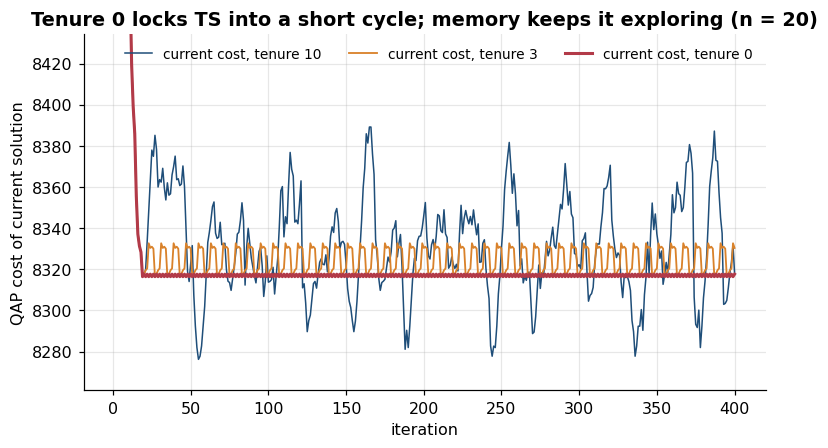

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for t, c, lw in zip([10, 3, 0], [PALETTE["blue"], PALETTE["orange"], PALETTE["red"]], [1.0, 1.2, 2.0]):
    ax.plot(np.arange(1, 401), runs_c[t]["cur_trace"], color=c, lw=lw, label=f"current cost, tenure {t}")
tail = np.concatenate([runs_c[t]["cur_trace"][20:] for t in (0, 3, 10)])
ax.set_ylim(tail.min() - 15, tail.max() + 45)       # zoom on the post-descent phase (initial descent is clipped)
ax.set_xlabel("iteration"); ax.set_ylabel("QAP cost of current solution")
ax.set_title("Tenure 0 locks TS into a short cycle; memory keeps it exploring (n = 20)")
ax.legend(loc="upper right", ncol=3, fontsize=9)
savefig("w3_ts_cycling.png"); plt.show()

## 5. Effect of the tenure: quality vs memory length

Too short a tenure permits cycling (previous cell); too long a tenure forbids so many moves that the best
*admissible* move is often poor and the search is driven almost at random (over-restriction). The sweet spot is
problem-dependent — for QAP, Taillard's robust TS draws it around $n$. We run TS on 3 random instances with
$n = 20$ from 8 seeds each, with a fixed budget of $600 \times 190 = 114\,000$ neighbour evaluations, and report the
gap to the best cost found by *any* run on that instance (best-known value, since $n = 20$ is beyond enumeration).

In [8]:
t0 = time.time()
tenures = [0, 1, 2, 4, 7, 10, 15, 20, 30, 50, 80, 120]
n_inst, n_seeds, n_it = 3, 8, 600
insts = [random_qap(20, np.random.default_rng(200 + i)) for i in range(n_inst)]
R = np.zeros((len(tenures), n_inst, n_seeds))
for a, t in enumerate(tenures):
    for i, (Fi, Di) in enumerate(insts):
        for sd in range(n_seeds):
            R[a, i, sd] = tabu_search_qap(Fi, Di, n_it, t, np.random.default_rng(1000 * i + sd))["best"]
best_known = R.min(axis=(0, 2))
gap = 100 * (R - best_known[None, :, None]) / best_known[None, :, None]
G = gap.reshape(len(tenures), -1)
med, q1, q3 = np.median(G, 1), np.percentile(G, 25, 1), np.percentile(G, 75, 1)
for t, m, a_, b_ in zip(tenures, med, q1, q3):
    print(f"tenure {t:>4}: median gap {m:5.2f}%   IQR [{a_:5.2f}, {b_:5.2f}]")
print(f"({time.time() - t0:.1f} s)")
i_best = int(np.argmin(med))
check_true(med[0] > med[i_best] and med[-1] > med[i_best],
           "U-shape: both tenure 0 and the largest tenure are worse than the best intermediate tenure")

tenure    0: median gap  1.77%   IQR [ 0.93,  2.33]
tenure    1: median gap  1.39%   IQR [ 0.71,  2.07]
tenure    2: median gap  1.33%   IQR [ 0.58,  2.07]
tenure    4: median gap  1.16%   IQR [ 0.58,  1.92]
tenure    7: median gap  0.60%   IQR [ 0.23,  1.32]
tenure   10: median gap  0.34%   IQR [ 0.00,  0.93]
tenure   15: median gap  0.36%   IQR [ 0.00,  0.74]
tenure   20: median gap  0.18%   IQR [ 0.00,  0.61]
tenure   30: median gap  0.23%   IQR [ 0.12,  0.37]
tenure   50: median gap  0.31%   IQR [ 0.11,  0.60]
tenure   80: median gap  0.56%   IQR [ 0.22,  0.95]
tenure  120: median gap  0.57%   IQR [ 0.23,  1.14]
(42.4 s)
[PASS] U-shape: both tenure 0 and the largest tenure are worse than the best intermediate tenure


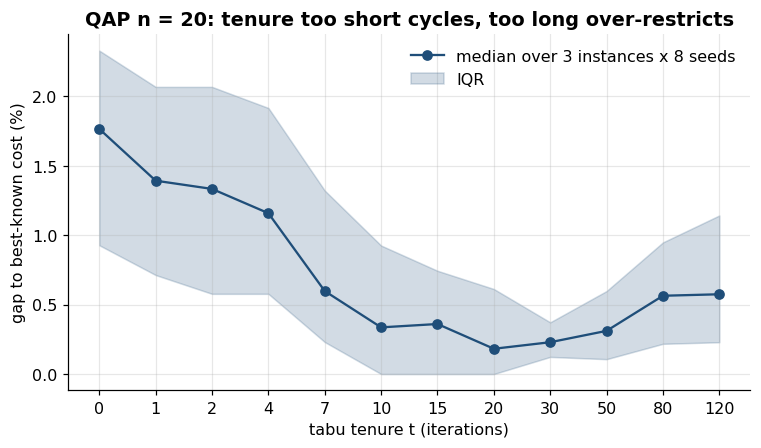

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(tenures))
ax.plot(x, med, "o-", color=PALETTE["blue"], label="median over 3 instances x 8 seeds")
ax.fill_between(x, q1, q3, color=PALETTE["blue"], alpha=0.2, label="IQR")
ax.set_xticks(x, [str(t) for t in tenures])
ax.set_xlabel("tabu tenure t (iterations)"); ax.set_ylabel("gap to best-known cost (%)")
ax.set_title("QAP n = 20: tenure too short cycles, too long over-restricts")
ax.legend()
savefig("w3_ts_tenure.png"); plt.show()

## 6. Candidate lists and aspiration at equal evaluation budget

When full-neighbourhood deltas cannot be maintained incrementally, a TS iteration costs $|M(x)|$ evaluations.
A *candidate list* examines only a random fraction $\rho$ of the moves, buying $1/\rho$ times more iterations for
the same budget, at the price of taking a worse "best" move. We also switch off aspiration to see what the
override buys. Budget: $60\,000$ neighbour evaluations per run, tenure 10, 3 instances × 8 seeds.

In [10]:
t0 = time.time()
budget = 60_000
variants = [("full, aspiration", 1.0, True), ("full, no aspiration", 1.0, False),
            ("cand. list 50%", 0.5, True), ("cand. list 25%", 0.25, True), ("cand. list 10%", 0.1, True)]
V = np.zeros((len(variants), n_inst, n_seeds))
for a, (name, frac, asp) in enumerate(variants):
    for i, (Fi, Di) in enumerate(insts):
        for sd in range(n_seeds):
            V[a, i, sd] = tabu_search_qap(Fi, Di, 10**7, 10, np.random.default_rng(1000 * i + sd), aspiration=asp,
                                          cand_frac=frac, max_evals=budget)["best"]
bk = np.minimum(best_known, V.min(axis=(0, 2)))
GV = (100 * (V - bk[None, :, None]) / bk[None, :, None]).reshape(len(variants), -1)
for (name, _, _), g in zip(variants, GV):
    print(f"{name:>22}: median gap {np.median(g):5.2f}%  IQR [{np.percentile(g, 25):5.2f}, {np.percentile(g, 75):5.2f}]")
print(f"({time.time() - t0:.1f} s)")

      full, aspiration: median gap  0.50%  IQR [ 0.00,  0.93]
   full, no aspiration: median gap  0.54%  IQR [ 0.12,  0.99]
        cand. list 50%: median gap  0.71%  IQR [ 0.47,  0.91]
        cand. list 25%: median gap  0.55%  IQR [ 0.22,  0.67]
        cand. list 10%: median gap  0.73%  IQR [ 0.60,  0.92]
(28.2 s)


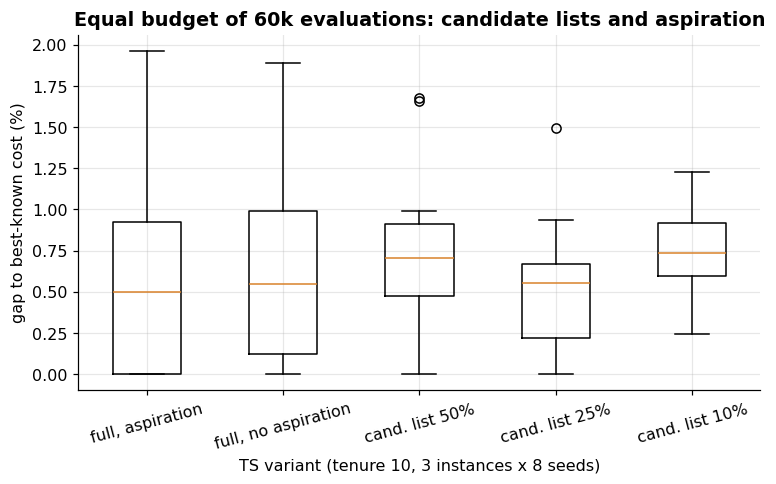

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.boxplot(list(GV), tick_labels=[v[0] for v in variants], widths=0.5)
ax.set_ylabel("gap to best-known cost (%)"); ax.set_xlabel("TS variant (tenure 10, 3 instances x 8 seeds)")
ax.set_title("Equal budget of 60k evaluations: candidate lists and aspiration")
plt.setp(ax.get_xticklabels(), rotation=15)
savefig("w3_ts_candidates.png"); plt.show()

**Reading the results.** The printed table is the evidence; the qualitative lessons are that the tenure curve is
U-shaped (cycling on the left, over-restriction on the right) and that candidate lists are a genuine design lever
rather than a free lunch: they shift the balance between the *quality of each step* and the *number of steps*
affordable within the budget. At this budget and sample size (24 runs per variant) the IQRs of the five variants
overlap heavily (every median lies inside the IQR of the full-neighbourhood variant with aspiration), so the
experiment does *not* single out a winner — switching aspiration off or
sampling 10–50% of the swaps changes the median gap by only a few tenths of a percent. The same trade-off appears in AI practice — e.g. local search over neural-architecture
or hyperparameter configurations, where one "evaluation" is a training run and the full neighbourhood is
unaffordable, so candidate lists (sampled neighbours) plus a tabu memory of recently changed hyperparameters is a
natural design.

## Key takeaways

- Tabu search = best-admissible-move local search + adaptive memory. Uphill moves are *always* accepted when they
  are the best admissible ones; memory, not randomness, prevents immediate return.
- Tabu lists store **attributes** of moves (here: facility–location pairs) with a **tenure**, not whole solutions:
  $O(1)$ tests, region-level prohibition, at the price of over-restriction that **aspiration by objective** repairs.
- Efficient TS lives or dies by **delta evaluation**: for QAP swaps, $O(n)$ per move and Taillard's $O(1)$-per-entry
  matrix update give $O(n^2)$ per full-neighbourhood iteration; both were validated against recomputation.
- With tenure 0, TS is a deterministic map on a finite set and provably cycles; the experiment shows a short cycle
  within a few iterations of the first local optimum.
- Solution quality vs tenure is U-shaped; candidate lists trade step quality for number of steps at a fixed
  evaluation budget.

## Exercises

1. ★ (a) Show that with aspiration by objective, an aspirated tabu move can never lead to a solution visited before.
   (b) Show that the weaker rule "aspirate a tabu move if it is better than the *current* solution" gives no such
   guarantee: construct a function on $\lbrace 0,1 \rbrace^n$ (bit-flip moves) with a non-global local minimum $x$
   from which TS with this rule returns to $x$ every second iteration forever, whatever the tenure, whereas plain
   aspiration by objective with tenure $t \ge n$ reaches the global optimum.
2. ★ Repeat the tenure sweep of Section 5 with the weak ("both") tabu-activation rule. How does the optimal
   tenure shift, and why? Relate your answer to the fraction of the $n^2$ facility–location attributes that are
   tabu at a given time.
3. ★★ Derive the swap delta for the **asymmetric** QAP (general $F$, $D$ with possibly non-zero diagonals) and
   validate it against `qap_cost` on random asymmetric matrices.
4. ★★ Prove that the tenure-$t$ TS with deterministic tie-breaking on a finite space is eventually periodic, and give
   an upper bound on the period in terms of $|S|$, $n$ and $t$. Construct a tiny instance where the period with
   $t = 1$ is longer than 2.
5. ★★ Replace random candidate lists by an *elite candidate list*: every $L$ iterations evaluate all moves, keep the
   best $m$ and only re-evaluate those in between. Compare with random candidate lists at equal evaluation budget.
6. ★★★ Apply this TS to hyperparameter search for a small model (e.g. ridge regression with discretised
   regularisation, polynomial degree and feature scaling choices) where each evaluation is a cross-validation run.
   Design the move attributes and tenure, and compare with random search at equal numbers of model fits.